Members: Ma. Kristal Czassandra A. Rivera Anwil Shien Oli Harold James Enciso John Jefferson Catibog Kriztoffer Ryan Hernandez Joshua Nuevo Lanze Ruzzel Orleans

Section: BSCPE Ladderize


## CPE017 - Digital Signal Processing

This notebook contains discussion and activities for Module 2: Harmonics

## Harmonic Structure

* Set of sinusoids they are made up of.

## Waveforms and harmonics
* Triangle waveform is like a straight-line version of a
sinusoid.

Create a triangle signal and plot a 3 period segment.

In [1]:
!git clone https://github.com/AllenDowney/ThinkDSP.git

Cloning into 'ThinkDSP'...
remote: Enumerating objects: 2733, done.
remote: Counting objects: 100% (321/321), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 2733 (delta 267), reused 241 (delta 241), pack-reused 2412 (from 1)
Receiving objects: 100% (2733/2733), 247.12 MiB | 26.53 MiB/s, done.
Resolving deltas: 100% (1504/1504), done.


In [2]:
import sys
sys.path.append('/content/ThinkDSP/code')

In [3]:
import thinkdsp
import matplotlib.pyplot as plt

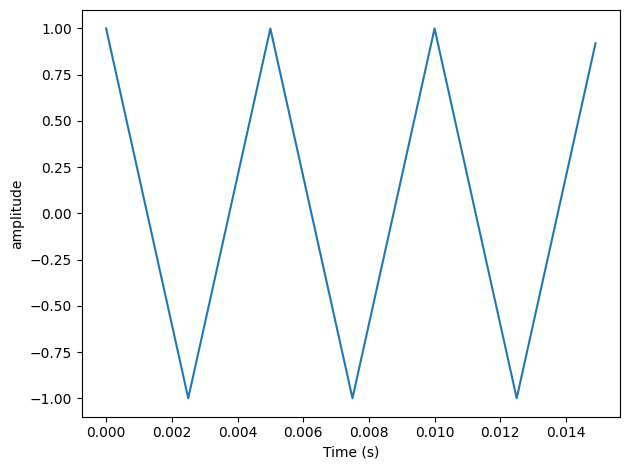

In [4]:
from thinkdsp import TriangleSignal
from thinkdsp import decorate

signal = TriangleSignal(200)
duration = signal.period*3
segment = signal.make_wave(duration, framerate=10000)
segment.plot()
decorate(xlabel='Time (s)', ylabel="amplitude")

Make a wave and play it.

In [5]:
wave = signal.make_wave(duration=2, framerate=10000)
wave.apodize()
wave.make_audio()

Compute its spectrum and plot it.

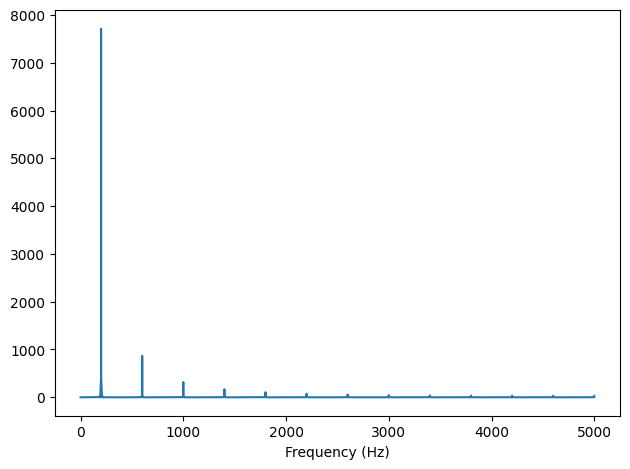

In [6]:
spectrum = wave.make_spectrum()
spectrum.plot()
decorate(xlabel='Frequency (Hz)')

Make a square signal and plot a 3 period segment.

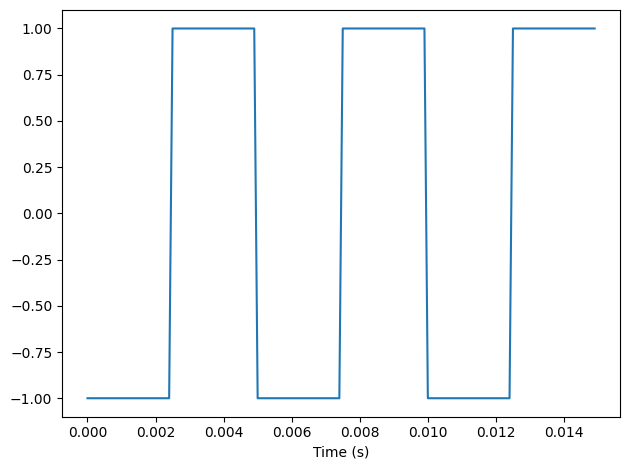

In [7]:
from thinkdsp import SquareSignal
import thinkdsp

signal = SquareSignal(200)
duration = signal.period*3
segment = signal.make_wave(duration, framerate=10000)
segment.plot()
decorate(xlabel='Time (s)')

Make a wave and play it.

In [8]:
wave = signal.make_wave(duration=0.5, framerate=10000)
wave.apodize()
wave.make_audio()

Compute its spectrum and plot it.

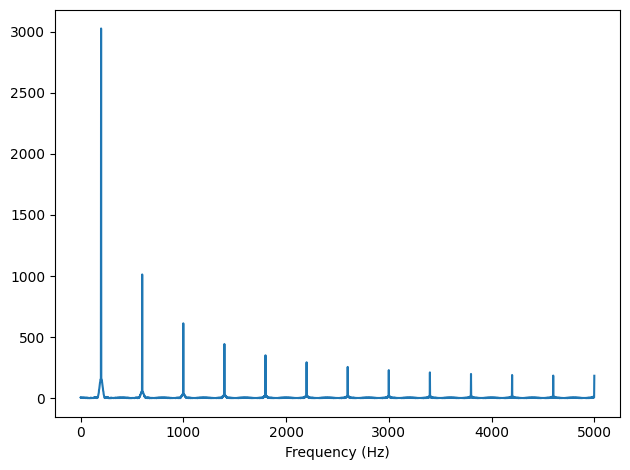

In [9]:
spectrum = wave.make_spectrum()
spectrum.plot()
decorate(xlabel='Frequency (Hz)')

Create a sawtooth signal and plot a 3 period segment.

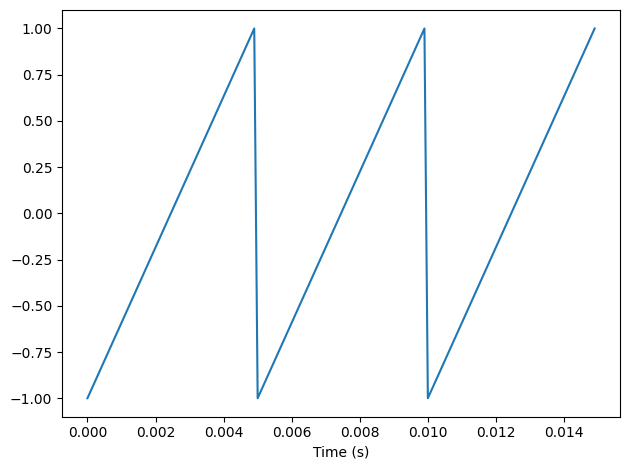

In [10]:
from thinkdsp import SawtoothSignal

signal = SawtoothSignal(200)
duration = signal.period*3
segment = signal.make_wave(duration, framerate=10000)
segment.plot()
decorate(xlabel='Time (s)')

Make a wave and play it.

In [11]:
wave = signal.make_wave(duration=0.5, framerate=10000)
wave.apodize()
wave.make_audio()

Compute its spectrum and plot it.

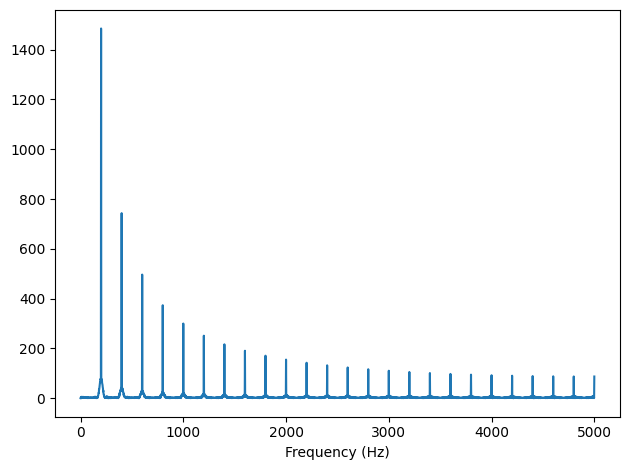

In [12]:
spectrum = wave.make_spectrum()
spectrum.plot()
decorate(xlabel='Frequency (Hz)')

### Aliasing
* one of the most important phenomena in digital signal
processing

Make a cosine signal at 4500 Hz, make a wave at framerate 10 kHz, and plot 5 periods.

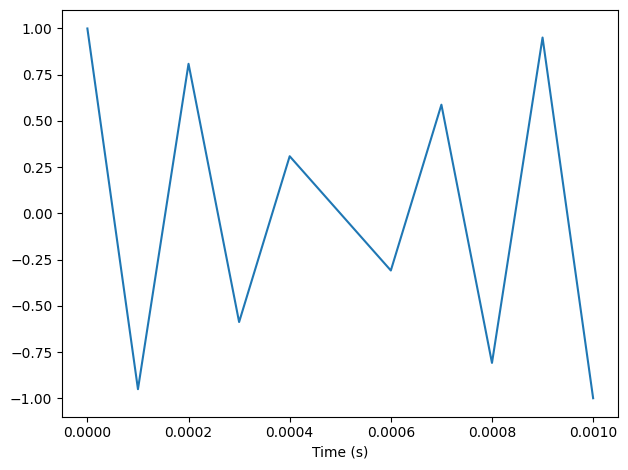

In [13]:
from thinkdsp import CosSignal

signal = CosSignal(4500)
duration = signal.period*5
segment = signal.make_wave(duration, framerate=10000)
segment.plot()
decorate(xlabel='Time (s)')

Make a cosine signal at 5500 Hz, make a wave at framerate 10 kHz, and plot the same duration.

With framerate 10 kHz, the folding frequency is 5 kHz, so a 4500 Hz signal and a 5500 Hz signal look exactly the same.

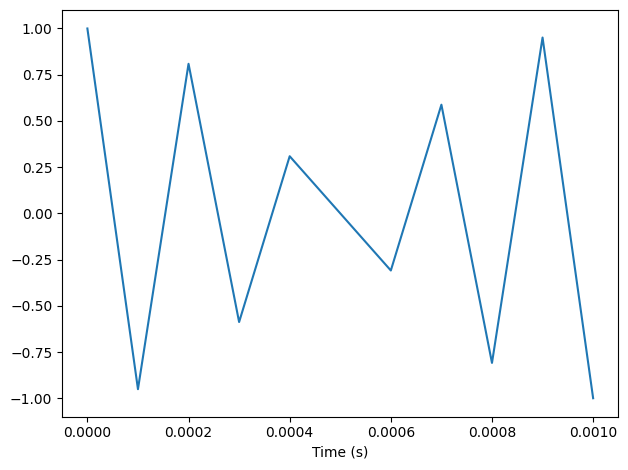

In [14]:
signal = CosSignal(5500)
segment = signal.make_wave(duration, framerate=10000)
segment.plot()
decorate(xlabel='Time (s)')

Make a triangle signal and plot the spectrum.  See how the harmonics get folded.

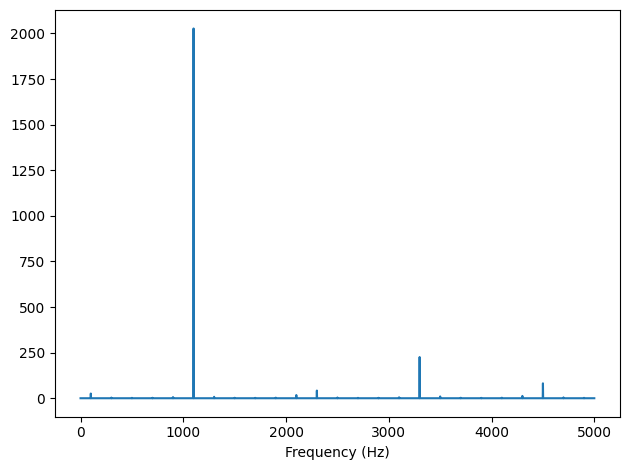

In [15]:
signal = TriangleSignal(1100)
segment = signal.make_wave(duration=0.5, framerate=10000)
spectrum = segment.make_spectrum()
spectrum.plot()
decorate(xlabel='Frequency (Hz)')

## Amplitude and phase

Make a sawtooth wave.

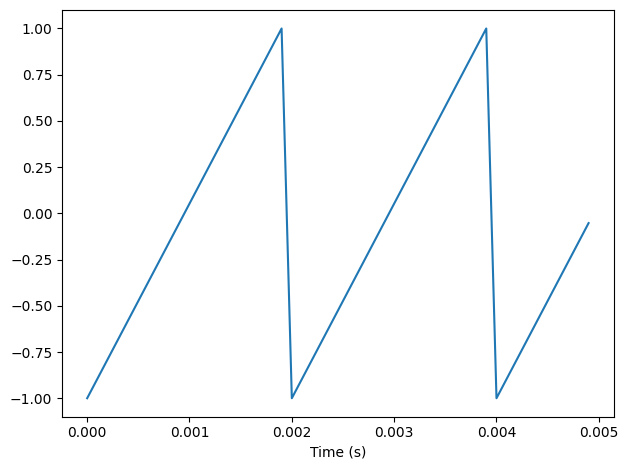

In [16]:
signal = SawtoothSignal(500)
wave = signal.make_wave(duration=1, framerate=10000)
segment = wave.segment(duration=0.005)
segment.plot()
decorate(xlabel='Time (s)')

Play it.

In [17]:
wave.make_audio()

Extract the wave array and compute the real FFT (which is just an FFT optimized for real inputs).

In [18]:
import numpy as np

hs = np.fft.rfft(wave.ys)
hs

array([ 5.11590770e-13+0.00000000e+00j,  2.19700679e-13-1.34559298e-13j,
       -2.09548671e-13-6.74603523e-14j, ...,
        4.19606174e-13+3.46000979e-14j, -5.63280756e-13+5.74915022e-14j,
       -5.26315789e+02+0.00000000e+00j])

Compute the frequencies that match up with the elements of the FFT.

In [19]:
n = len(wave.ys)                 # number of samples
d = 1 / wave.framerate           # time between samples
fs = np.fft.rfftfreq(n, d)
fs

array([0.000e+00, 1.000e+00, 2.000e+00, ..., 4.998e+03, 4.999e+03,
       5.000e+03])

Plot the magnitudes vs the frequencies.

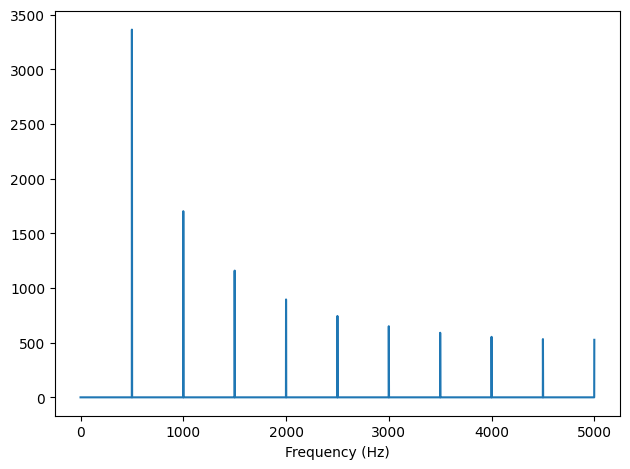

In [20]:
import matplotlib.pyplot as plt

magnitude = np.absolute(hs)
plt.plot(fs, magnitude)
decorate(xlabel='Frequency (Hz)')

Plot the phases vs the frequencies.

array([ 0.        , -0.54953563, -2.83013846, ...,  0.08227237,
        3.03987942,  3.14159265])

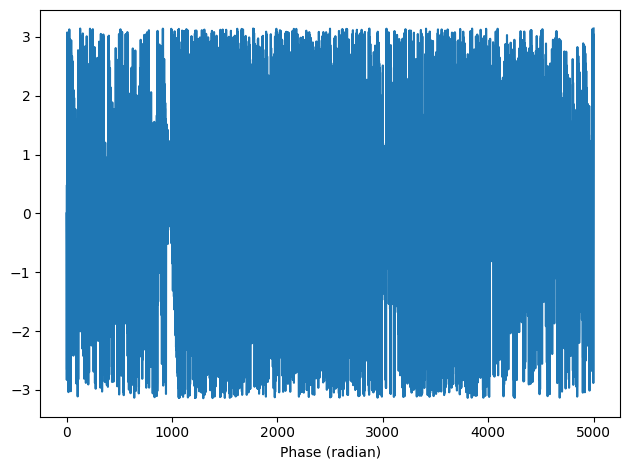

In [21]:
angle = np.angle(hs)
plt.plot(fs, angle)
decorate(xlabel='Phase (radian)')
angle

## What does phase sound like?

Shuffle the phases.

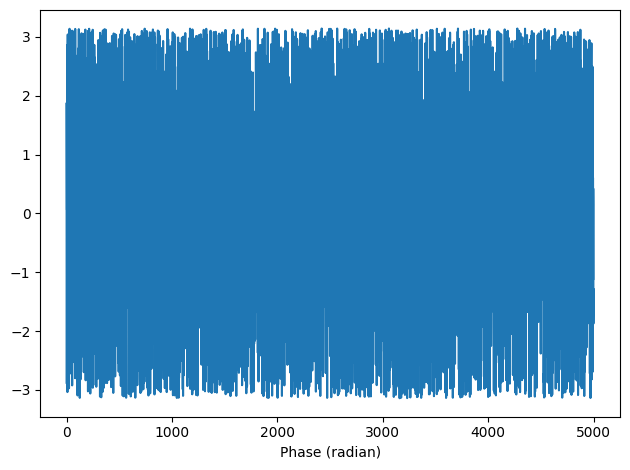

In [22]:
import random
random.shuffle(angle)
plt.plot(fs, angle)
decorate(xlabel='Phase (radian)')

Put the shuffled phases back into the spectrum.  Each element in `hs` is a complex number with magnitude $A$ and phase $\phi$, with which we can compute $A e^{i \phi}$

In [23]:
i = complex(0, 1)
spectrum = wave.make_spectrum()
spectrum.hs = magnitude * np.exp(i * angle)

Convert the spectrum back to a wave (which uses irfft).

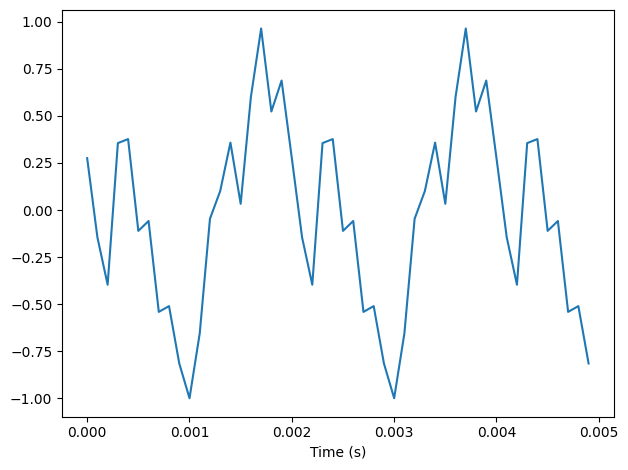

In [24]:
wave2 = spectrum.make_wave()
wave2.normalize()
segment = wave2.segment(duration=0.005)
segment.plot()
decorate(xlabel='Time (s)')

Play the wave with the shuffled phases.

In [25]:
wave2.make_audio()

For comparison, here's the original wave again.

In [26]:
wave.make_audio()

Although the two signals have different waveforms, they have the same frequency components with the same amplitudes.  They differ only in phase.

## Aliasing interaction

The following interaction explores the effect of aliasing on the harmonics of a sawtooth signal.

In [27]:
def view_harmonics(freq, framerate):
    """Plot the spectrum of a sawtooth signal.

    freq: frequency in Hz
    framerate: in frames/second
    """
    signal = SawtoothSignal(freq)
    wave = signal.make_wave(duration=0.5, framerate=framerate)
    spectrum = wave.make_spectrum()
    spectrum.plot(color='C0')
    decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')
    display(wave.make_audio())

In [28]:
from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets

slider1 = widgets.FloatSlider(min=100, max=10000, value=100, step=100)
slider2 = widgets.FloatSlider(min=5000, max=40000, value=10000, step=1000)
interact(view_harmonics, freq=slider1, framerate=slider2);

interactive(children=(FloatSlider(value=100.0, description='freq', max=10000.0, min=100.0, step=100.0), FloatS…

## Exercise 1
Generate a square signal with a frequency of 2000 Hz and create a waveform by sampling it at a rate of 15,000 frames per second. When you visualize the spectrum, you'll notice that many of the harmonics have undergone aliasing. When you listen to the resulting waveform, can you perceive the effects of the aliased harmonics?

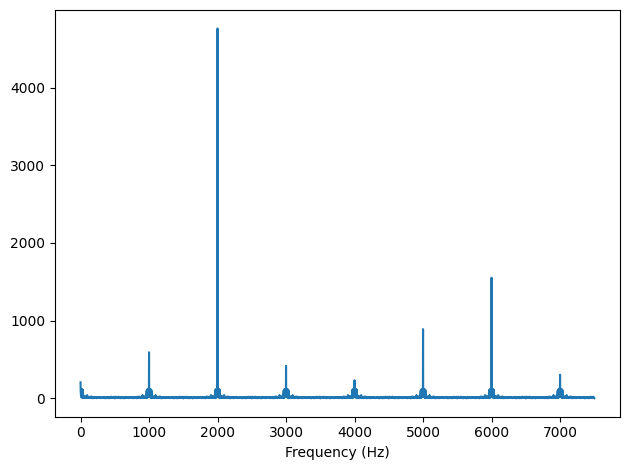

In [29]:
# Your solution here
square = SquareSignal(2000).make_wave(duration=0.5, framerate=15000)
square.make_spectrum().plot()
decorate(xlabel='Frequency (Hz)')

## Conclusion
In this activity, we explored different types of periodic signals, specifically triangle, square, and sawtooth waves. We saw how thinkdsp allows us to easily generate these signals and visualize them over a short duration.

Crucially, we also demonstrated the concept of aliasing. By comparing a high sample rate with a low sample rate for a fast-changing signal, we observed how an insufficient sample rate can distort the perceived frequency and shape of the original signal, making it appear as a different, lower-frequency signal. This highlights the importance of choosing an appropriate sample rate to accurately capture and represent a signal.